In [1]:
import os
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub


In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

print("Experiment: ResNet50 Focal Loss + 5-Fold CV")
print("Images: Original")
print("Focal alpha: 0.29")
print("Focal gamma: 2.0")
print("Dropout: Disabled")
print("Balanced batches: Disabled")
print("Class weights: Disabled")

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Experiment: ResNet50 Focal Loss + 5-Fold CV
Images: Original
Focal alpha: 0.29
Focal gamma: 2.0
Dropout: Disabled
Balanced batches: Disabled
Class weights: Disabled


In [3]:
dataset_path = kagglehub.dataset_download(
    "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
)

image_root = Path(dataset_path) / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [4]:
class_mapping = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_mapping.items():
    class_folder = image_root / class_name

    for file_path in sorted(class_folder.iterdir()):
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(file_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))

print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

initial_train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

initial_validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"]
)

development_df = pd.concat(
    [initial_train_df, initial_validation_df],
    ignore_index=True
)

development_df = development_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Development images:", len(development_df))
print(development_df["label"].value_counts().sort_index())

print("\nUntouched test images:", len(test_df))
print(test_df["label"].value_counts().sort_index())

Development images: 37400
label
0    10880
1    26520
Name: count, dtype: int64

Untouched test images: 6600
label
0    1920
1    4680
Name: count, dtype: int64


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_original_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, tf.cast(label, tf.float32)

def create_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].values,
        dataframe["label"].values
    ))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_original_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    return dataset.prefetch(AUTOTUNE)

test_dataset = create_dataset(test_df)

print("Original-image pipeline created.")
print("Test dataset batches:", len(test_dataset))

Original-image pipeline created.
Test dataset batches: 207


I0000 00:00:1789404653.714943      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789404653.717829      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
image_batch, label_batch = next(iter(test_dataset))

print("Image batch shape:", image_batch.shape)
print("Label batch shape:", label_batch.shape)

print(
    "Pixel range:",
    float(tf.reduce_min(image_batch)),
    "to",
    float(tf.reduce_max(image_batch))
)

print("First labels:", label_batch[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0
First labels: [1. 1. 1. 1. 1. 1. 1. 0. 1. 1.]


In [8]:
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5

stratified_kfold = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

fold_splits = list(
    stratified_kfold.split(
        development_df["filepath"],
        development_df["label"]
    )
)

for fold_number, (train_indices, val_indices) in enumerate(
    fold_splits,
    start=1
):
    fold_train_labels = development_df.iloc[
        train_indices
    ]["label"]

    fold_val_labels = development_df.iloc[
        val_indices
    ]["label"]

    print(
        f"Fold {fold_number}: "
        f"Training = {len(train_indices)}, "
        f"Validation = {len(val_indices)}"
    )

    print(
        "  Train counts:",
        fold_train_labels.value_counts().sort_index().to_dict()
    )
    print(
        "  Validation counts:",
        fold_val_labels.value_counts().sort_index().to_dict()
    )

Fold 1: Training = 29920, Validation = 7480
  Train counts: {0: 8704, 1: 21216}
  Validation counts: {0: 2176, 1: 5304}
Fold 2: Training = 29920, Validation = 7480
  Train counts: {0: 8704, 1: 21216}
  Validation counts: {0: 2176, 1: 5304}
Fold 3: Training = 29920, Validation = 7480
  Train counts: {0: 8704, 1: 21216}
  Validation counts: {0: 2176, 1: 5304}
Fold 4: Training = 29920, Validation = 7480
  Train counts: {0: 8704, 1: 21216}
  Validation counts: {0: 2176, 1: 5304}
Fold 5: Training = 29920, Validation = 7480
  Train counts: {0: 8704, 1: 21216}
  Validation counts: {0: 2176, 1: 5304}


In [9]:
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

FOCAL_ALPHA = 0.29
FOCAL_GAMMA = 2.0

print("Number of folds:", N_SPLITS)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs per fold:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Focal alpha:", FOCAL_ALPHA)
print("Focal gamma:", FOCAL_GAMMA)

print("Preprocessing: Original images")
print("Data augmentation: Disabled")
print("Dropout rate: Disabled")
print("Natural batches: Enabled")
print("Class weights: Disabled")

Number of folds: 5
Image size: (224, 224)
Batch size: 32
Maximum epochs per fold: 30
Early-stopping patience: 5
Learning rate: 0.0001
Focal alpha: 0.29
Focal gamma: 2.0
Preprocessing: Original images
Data augmentation: Disabled
Dropout rate: Disabled
Natural batches: Enabled
Class weights: Disabled


In [10]:
def build_focal_resnet50():
    tf.keras.utils.set_random_seed(SEED)

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))

    x = tf.keras.applications.resnet50.preprocess_input(inputs)

    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )

    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs,
        name="ResNet50_Focal_CV"
    )

    focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
        alpha=FOCAL_ALPHA,
        gamma=FOCAL_GAMMA,
        from_logits=False
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss=focal_loss,
        metrics=["accuracy"]
    )

    return model

preview_model = build_focal_resnet50()

print("Total parameters:", preview_model.count_params())
print(
    "Trainable parameters:",
    sum(tf.keras.backend.count_params(weight)
        for weight in preview_model.trainable_weights)
)
print("ResNet50 frozen: True")
print("Dropout enabled: False")

preview_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True
Dropout enabled: False


Model: "ResNet50_Focal_CV"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
def create_fold_callbacks(fold_number):
    model_path = (
        f"/kaggle/working/"
        f"resnet50_focal_cv_fold_{fold_number}_best.keras"
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    return callbacks, model_path

print("Fold callback function created.")

Fold callback function created.


In [12]:
del preview_model
tf.keras.backend.clear_session()
gc.collect()

fold_history_frames = []
fold_summaries = []
fold_model_paths = []

for fold_number, (train_indices, val_indices) in enumerate(
    fold_splits,
    start=1
):
    print(
        f"\n{'=' * 20} "
        f"FOLD {fold_number}/{N_SPLITS} "
        f"{'=' * 20}"
    )

    fold_train_df = development_df.iloc[
        train_indices
    ].reset_index(drop=True)

    fold_val_df = development_df.iloc[
        val_indices
    ].reset_index(drop=True)

    fold_train_dataset = create_dataset(
        fold_train_df,
        training=True
    )

    fold_val_dataset = create_dataset(
        fold_val_df,
        training=False
    )

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_focal_resnet50()

    fold_callbacks, model_path = create_fold_callbacks(
        fold_number
    )

    history = model.fit(
        fold_train_dataset,
        validation_data=fold_val_dataset,
        epochs=MAX_EPOCHS,
        callbacks=fold_callbacks,
        verbose=1
    )

    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
    history_df.insert(0, "fold", fold_number)

    fold_history_frames.append(history_df)
    fold_model_paths.append(model_path)

    best_index = int(
        np.argmin(history.history["val_loss"])
    )

    fold_summaries.append({
        "Fold": fold_number,
        "Epochs Trained": len(history.history["loss"]),
        "Best Epoch": best_index + 1,
        "Best Val Loss": history.history["val_loss"][best_index],
        "Val Accuracy at Best Loss":
            history.history["val_accuracy"][best_index],
        "Highest Val Accuracy":
            max(history.history["val_accuracy"])
    })

    del model
    del fold_train_dataset
    del fold_val_dataset
    gc.collect()

all_fold_history = pd.concat(
    fold_history_frames,
    ignore_index=True
)

fold_summary_df = pd.DataFrame(fold_summaries)

all_fold_history.to_csv(
    "/kaggle/working/resnet50_focal_cv_history.csv",
    index=False
)

fold_summary_df.to_csv(
    "/kaggle/working/resnet50_focal_cv_fold_summary.csv",
    index=False
)

display(fold_summary_df)
print("All five folds finished and saved.")


==================== FOLD 1/5 ====================
Epoch 1/30
  2/935 ━━━━━━━━━━━━━━━━━━━━ 1:11 76ms/step - accuracy: 0.7344 - loss: 0.1655  

I0000 00:00:1789404696.333560     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6157 - loss: 0.0746
Epoch 1: val_loss improved from None to 0.05460, saving model to /kaggle/working/resnet50_focal_cv_fold_1_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_focal_cv_fold_1_best.keras
935/935 ━━━━━━━━━━━━━━━━━━━━ 117s 111ms/step - accuracy: 0.6891 - loss: 0.0630 - val_accuracy: 0.7491 - val_loss: 0.0546 - learning_rate: 1.0000e-04
Epoch 2/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7617 - loss: 0.0525
Epoch 2: val_loss improved from 0.05460 to 0.05087, saving model to /kaggle/working/resnet50_focal_cv_fold_1_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_focal_cv_fold_1_best.keras
935/935 ━━━━━━━━━━━━━━━━━━━━ 107s 114ms/step - accuracy: 0.7684 - loss: 0.0512 - val_accuracy: 0.7814 - val_loss: 0.0509 - learning_rate: 1.0000e-04
Epoch 3/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7765 - loss: 0.0494
Epoch 3: val_loss improved from 0.05087 t

,Fold,Epochs Trained,Best Epoch,Best Val Loss,Val Accuracy at Best Loss,Highest Val Accuracy
0,1,30,29,0.038914,0.834893,0.840909
1,2,30,29,0.038545,0.833021,0.839706
2,3,30,30,0.038089,0.816310,0.857487
3,4,30,29,0.037972,0.844652,0.852139
4,5,30,30,0.038015,0.840241,0.843449


All five folds finished and saved.


In [13]:
cv_summary = pd.DataFrame({
    "Metric": [
        "Best Validation Loss",
        "Validation Accuracy at Best Loss",
        "Highest Validation Accuracy",
        "Epochs Trained"
    ],
    "Mean": [
        fold_summary_df["Best Val Loss"].mean(),
        fold_summary_df["Val Accuracy at Best Loss"].mean(),
        fold_summary_df["Highest Val Accuracy"].mean(),
        fold_summary_df["Epochs Trained"].mean()
    ],
    "Standard Deviation": [
        fold_summary_df["Best Val Loss"].std(),
        fold_summary_df["Val Accuracy at Best Loss"].std(),
        fold_summary_df["Highest Val Accuracy"].std(),
        fold_summary_df["Epochs Trained"].std()
    ]
})

display(fold_summary_df)
display(cv_summary.round(4))

,Fold,Epochs Trained,Best Epoch,Best Val Loss,Val Accuracy at Best Loss,Highest Val Accuracy
0,1,30,29,0.038914,0.834893,0.840909
1,2,30,29,0.038545,0.833021,0.839706
2,3,30,30,0.038089,0.816310,0.857487
3,4,30,29,0.037972,0.844652,0.852139
4,5,30,30,0.038015,0.840241,0.843449


,Metric,Mean,Standard Deviation
0,Best Validation Loss,0.0383,0.0004
1,Validation Accuracy at Best Loss,0.8338,0.0108
2,Highest Validation Accuracy,0.8467,0.0077
3,Epochs Trained,30.0000,0.0000


In [14]:
fold_test_probabilities = []

for fold_number, model_path in enumerate(
    fold_model_paths,
    start=1
):
    print(f"Predicting with fold {fold_number}...")

    fold_model = tf.keras.models.load_model(
        model_path,
        compile=False
    )

    probabilities = fold_model.predict(
        test_dataset,
        verbose=1
    ).ravel()

    fold_test_probabilities.append(probabilities)

    del fold_model
    tf.keras.backend.clear_session()
    gc.collect()

fold_test_probabilities = np.vstack(
    fold_test_probabilities
)

ensemble_probabilities = np.mean(
    fold_test_probabilities,
    axis=0
)

ensemble_predictions = (
    ensemble_probabilities >= 0.5
).astype(int)

true_labels = test_df["label"].to_numpy()

print("Test images:", len(true_labels))
print("Fold prediction shape:", fold_test_probabilities.shape)
print("Ensemble probabilities:", len(ensemble_probabilities))
print("Ensemble predictions:", len(ensemble_predictions))
print(
    "First ensemble probabilities:",
    np.round(ensemble_probabilities[:10], 4)
)

Predicting with fold 1...
207/207 ━━━━━━━━━━━━━━━━━━━━ 28s 115ms/step
Predicting with fold 2...
207/207 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step
Predicting with fold 3...
207/207 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step
Predicting with fold 4...
207/207 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step
Predicting with fold 5...
207/207 ━━━━━━━━━━━━━━━━━━━━ 27s 109ms/step
Test images: 6600
Fold prediction shape: (5, 6600)
Ensemble probabilities: 6600
Ensemble predictions: 6600
First ensemble probabilities: [0.7179 0.692  0.6559 0.5667 0.7298 0.7475 0.7107 0.5332 0.9094 0.736 ]


In [15]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

ensemble_focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=True,
    alpha=FOCAL_ALPHA,
    gamma=FOCAL_GAMMA,
    from_logits=False
)

test_loss = float(
    ensemble_focal_loss(
        true_labels.reshape(-1, 1).astype(np.float32),
        ensemble_probabilities.reshape(-1, 1).astype(np.float32)
    ).numpy()
)

tn, fp, fn, tp = confusion_matrix(
    true_labels,
    ensemble_predictions
).ravel()

specificity = tn / (tn + fp)

test_accuracy = accuracy_score(
    true_labels, ensemble_predictions
)
balanced_accuracy = balanced_accuracy_score(
    true_labels, ensemble_predictions
)
precision = precision_score(
    true_labels, ensemble_predictions
)
recall = recall_score(
    true_labels, ensemble_predictions
)
f1 = f1_score(
    true_labels, ensemble_predictions
)
roc_auc = roc_auc_score(
    true_labels, ensemble_probabilities
)
pr_auc = average_precision_score(
    true_labels, ensemble_probabilities
)

print("Ensemble Focal Loss:", round(test_loss, 4))
print("Accuracy:", round(test_accuracy, 4))
print("Balanced Accuracy:", round(balanced_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall/Sensitivity:", round(recall, 4))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

Ensemble Focal Loss: 0.0387
Accuracy: 0.8297
Balanced Accuracy: 0.8282
Precision: 0.9203
Recall/Sensitivity: 0.8318
Specificity: 0.8245
F1-score: 0.8738
ROC-AUC: 0.9184
PR-AUC: 0.9644


In [16]:
fold_test_results = []

for fold_index, probabilities in enumerate(
    fold_test_probabilities,
    start=1
):
    predictions = (probabilities >= 0.5).astype(int)

    tn_f, fp_f, fn_f, tp_f = confusion_matrix(
        true_labels, predictions
    ).ravel()

    fold_test_results.append({
        "Model": f"Fold {fold_index}",
        "Accuracy": accuracy_score(true_labels, predictions),
        "Balanced Accuracy": balanced_accuracy_score(
            true_labels, predictions
        ),
        "Precision": precision_score(true_labels, predictions),
        "Recall": recall_score(true_labels, predictions),
        "Specificity": tn_f / (tn_f + fp_f),
        "F1-score": f1_score(true_labels, predictions),
        "ROC-AUC": roc_auc_score(true_labels, probabilities),
        "PR-AUC": average_precision_score(
            true_labels, probabilities
        )
    })

fold_test_results.append({
    "Model": "5-Fold Ensemble",
    "Accuracy": test_accuracy,
    "Balanced Accuracy": balanced_accuracy,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
})

fold_test_results_df = pd.DataFrame(fold_test_results)

display(fold_test_results_df.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC
0,Fold 1,0.8294,0.8252,0.9167,0.8353,0.8151,0.8741,0.9166,0.9635
1,Fold 2,0.8268,0.8223,0.9150,0.8331,0.8115,0.8722,0.9147,0.9625
2,Fold 3,0.8206,0.8327,0.9340,0.8038,0.8615,0.8640,0.9216,0.9658
3,Fold 4,0.8355,0.8279,0.9156,0.8459,0.8099,0.8794,0.9181,0.9642
4,Fold 5,0.8323,0.8260,0.9156,0.8410,0.8109,0.8767,0.9175,0.9639
5,5-Fold Ensemble,0.8297,0.8282,0.9203,0.8318,0.8245,0.8738,0.9184,0.9644


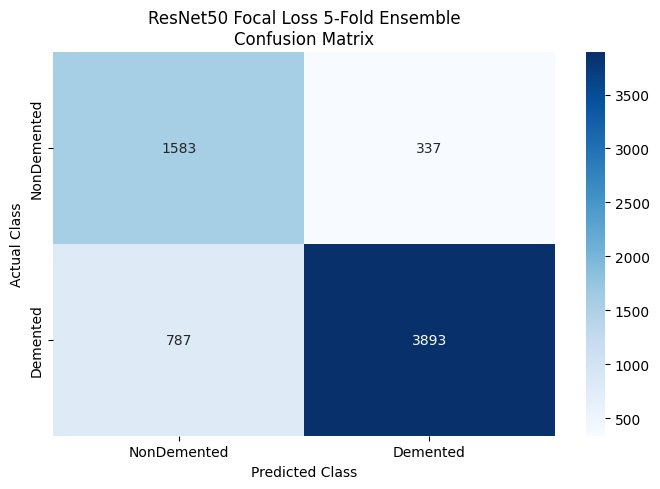

In [17]:
ensemble_cm = confusion_matrix(
    true_labels,
    ensemble_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    ensemble_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("ResNet50 Focal Loss 5-Fold Ensemble\nConfusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        ensemble_predictions,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

              precision    recall  f1-score   support

 NonDemented     0.6679    0.8245    0.7380      1920
    Demented     0.9203    0.8318    0.8738      4680

    accuracy                         0.8297      6600
   macro avg     0.7941    0.8282    0.8059      6600
weighted avg     0.8469    0.8297    0.8343      6600



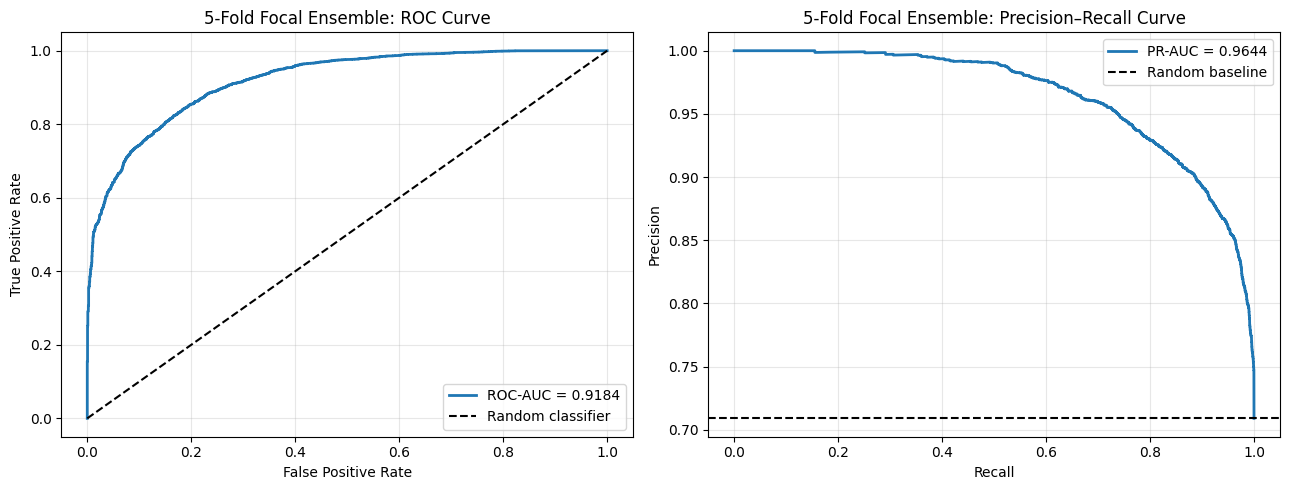

In [19]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(
    true_labels,
    ensemble_probabilities
)

pr_precision, pr_recall, _ = precision_recall_curve(
    true_labels,
    ensemble_probabilities
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fpr, tpr,
    linewidth=2,
    label=f"ROC-AUC = {roc_auc:.4f}"
)
axes[0].plot(
    [0, 1], [0, 1],
    "k--",
    label="Random classifier"
)
axes[0].set_title("5-Fold Focal Ensemble: ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.4f}"
)
axes[1].axhline(
    true_labels.mean(),
    color="black",
    linestyle="--",
    label="Random baseline"
)
axes[1].set_title("5-Fold Focal Ensemble: Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

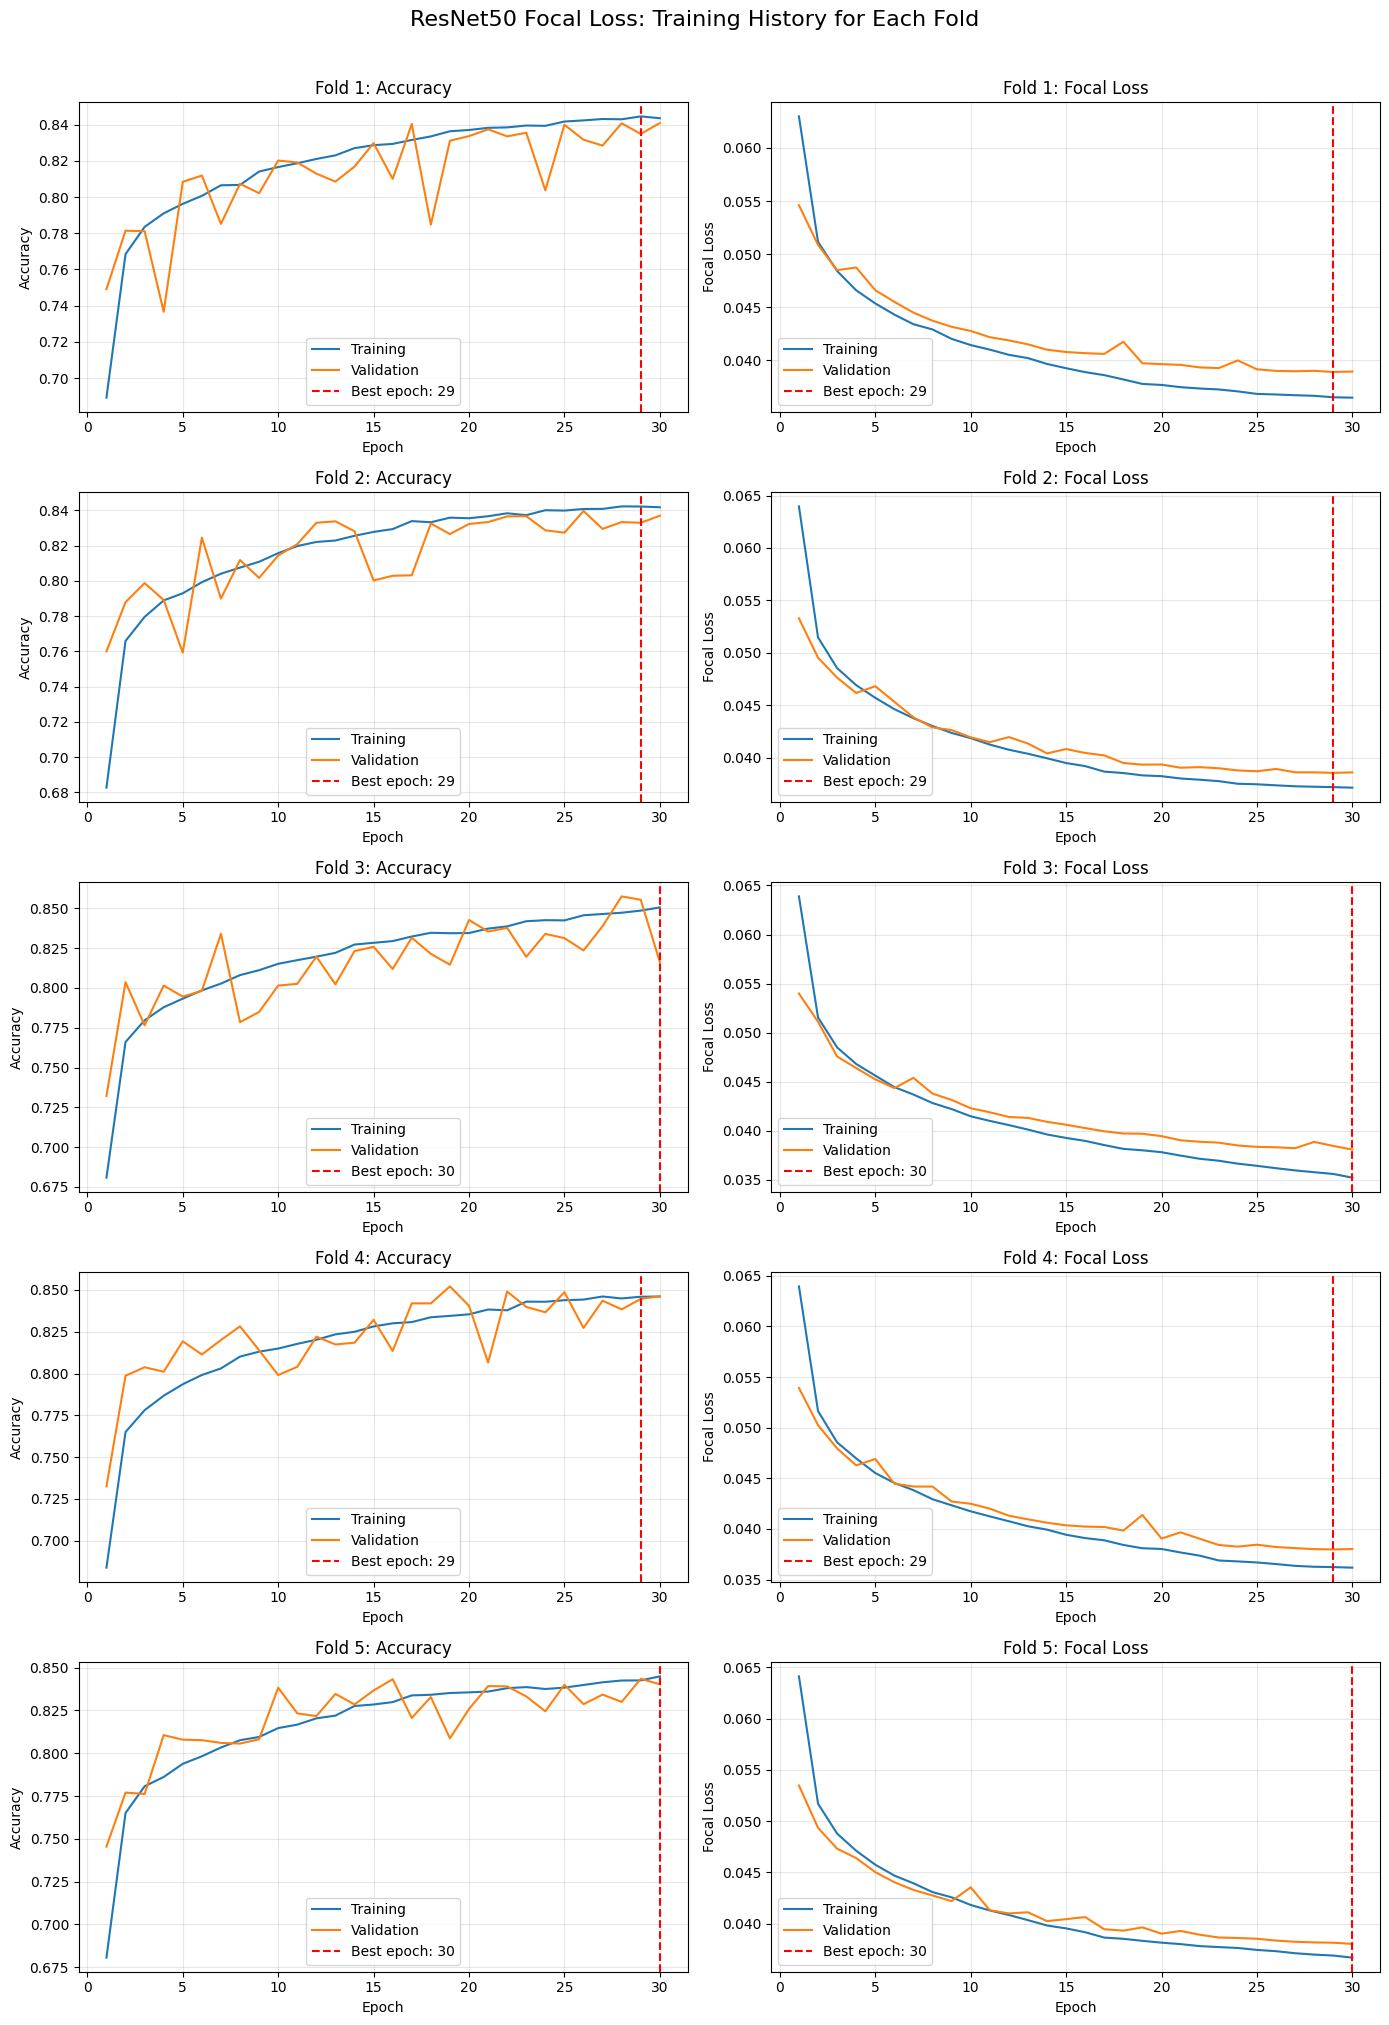

In [20]:
fig, axes = plt.subplots(
    N_SPLITS,
    2,
    figsize=(14, 4 * N_SPLITS)
)

for fold_number in range(1, N_SPLITS + 1):
    fold_history = all_fold_history[
        all_fold_history["fold"] == fold_number
    ]

    best_epoch = int(
        fold_summary_df.loc[
            fold_summary_df["Fold"] == fold_number,
            "Best Epoch"
        ].iloc[0]
    )

    accuracy_axis = axes[fold_number - 1, 0]
    loss_axis = axes[fold_number - 1, 1]

    accuracy_axis.plot(
        fold_history["epoch"],
        fold_history["accuracy"],
        label="Training"
    )
    accuracy_axis.plot(
        fold_history["epoch"],
        fold_history["val_accuracy"],
        label="Validation"
    )
    accuracy_axis.axvline(
        best_epoch,
        color="red",
        linestyle="--",
        label=f"Best epoch: {best_epoch}"
    )
    accuracy_axis.set_title(f"Fold {fold_number}: Accuracy")
    accuracy_axis.set_xlabel("Epoch")
    accuracy_axis.set_ylabel("Accuracy")
    accuracy_axis.legend()
    accuracy_axis.grid(alpha=0.3)

    loss_axis.plot(
        fold_history["epoch"],
        fold_history["loss"],
        label="Training"
    )
    loss_axis.plot(
        fold_history["epoch"],
        fold_history["val_loss"],
        label="Validation"
    )
    loss_axis.axvline(
        best_epoch,
        color="red",
        linestyle="--",
        label=f"Best epoch: {best_epoch}"
    )
    loss_axis.set_title(f"Fold {fold_number}: Focal Loss")
    loss_axis.set_xlabel("Epoch")
    loss_axis.set_ylabel("Focal Loss")
    loss_axis.legend()
    loss_axis.grid(alpha=0.3)

plt.suptitle(
    "ResNet50 Focal Loss: Training History for Each Fold",
    fontsize=16,
    y=1.01
)
plt.tight_layout()
plt.show()

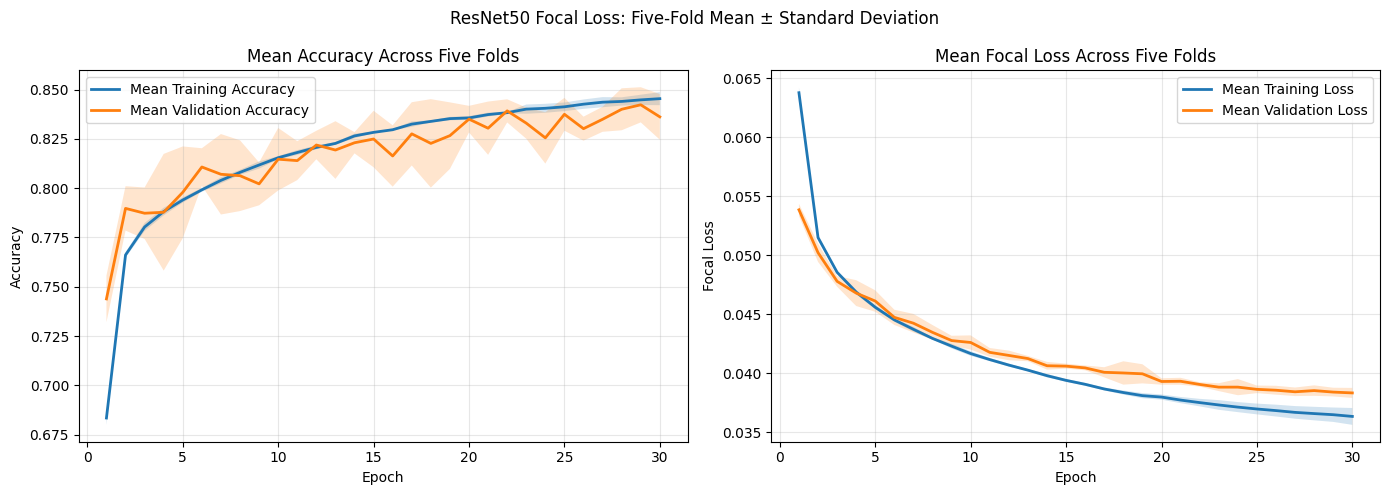

In [21]:
minimum_epochs = int(
    all_fold_history.groupby("fold")["epoch"].max().min()
)

common_history = all_fold_history[
    all_fold_history["epoch"] <= minimum_epochs
]

mean_history = common_history.groupby("epoch")[
    ["accuracy", "val_accuracy", "loss", "val_loss"]
].mean()

std_history = common_history.groupby("epoch")[
    ["accuracy", "val_accuracy", "loss", "val_loss"]
].std()

epochs = mean_history.index.to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    epochs,
    mean_history["accuracy"],
    label="Mean Training Accuracy",
    linewidth=2
)
axes[0].fill_between(
    epochs,
    mean_history["accuracy"] - std_history["accuracy"],
    mean_history["accuracy"] + std_history["accuracy"],
    alpha=0.2
)

axes[0].plot(
    epochs,
    mean_history["val_accuracy"],
    label="Mean Validation Accuracy",
    linewidth=2
)
axes[0].fill_between(
    epochs,
    mean_history["val_accuracy"] - std_history["val_accuracy"],
    mean_history["val_accuracy"] + std_history["val_accuracy"],
    alpha=0.2
)

axes[0].set_title("Mean Accuracy Across Five Folds")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs,
    mean_history["loss"],
    label="Mean Training Loss",
    linewidth=2
)
axes[1].fill_between(
    epochs,
    mean_history["loss"] - std_history["loss"],
    mean_history["loss"] + std_history["loss"],
    alpha=0.2
)

axes[1].plot(
    epochs,
    mean_history["val_loss"],
    label="Mean Validation Loss",
    linewidth=2
)
axes[1].fill_between(
    epochs,
    mean_history["val_loss"] - std_history["val_loss"],
    mean_history["val_loss"] + std_history["val_loss"],
    alpha=0.2
)

axes[1].set_title("Mean Focal Loss Across Five Folds")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Focal Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("ResNet50 Focal Loss: Five-Fold Mean ± Standard Deviation")
plt.tight_layout()
plt.show()

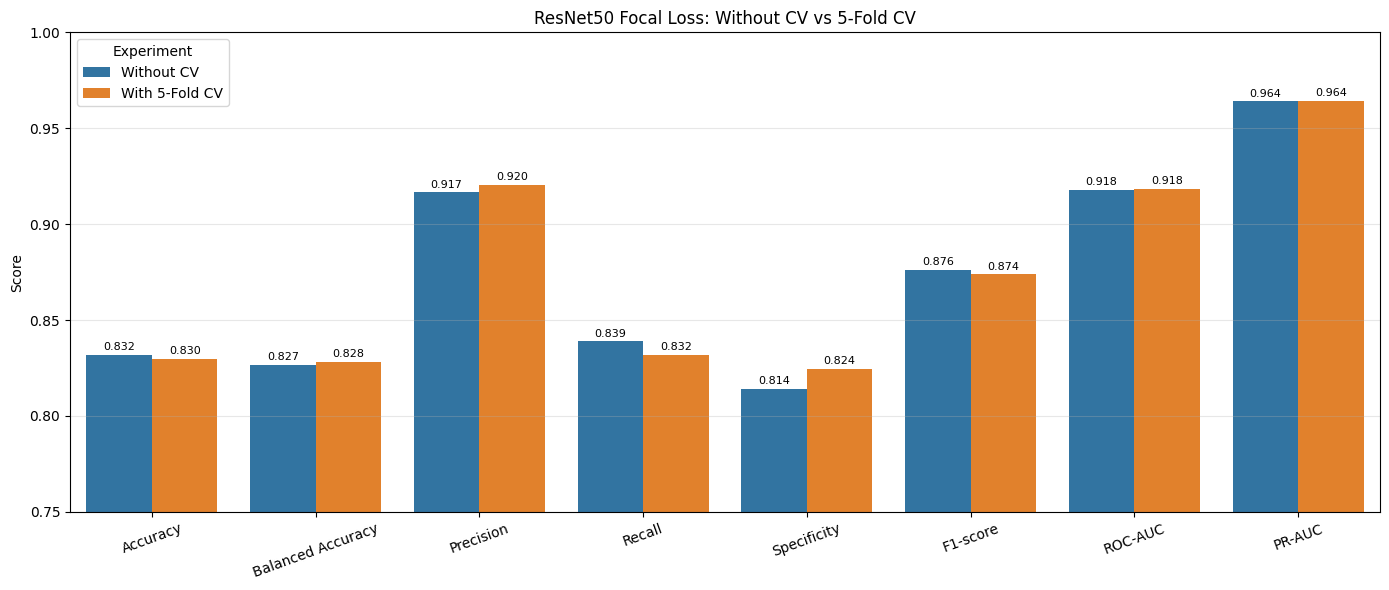

,Metric,Without CV,With 5-Fold CV
0,Accuracy,0.8317,0.8297
1,Balanced Accuracy,0.8265,0.8282
2,Precision,0.9166,0.9203
3,Recall,0.8389,0.8318
4,Specificity,0.8141,0.8245
5,F1-score,0.8760,0.8738
6,ROC-AUC,0.9177,0.9184
7,PR-AUC,0.9640,0.9644


In [22]:
cv_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy", "Balanced Accuracy", "Precision",
        "Recall", "Specificity", "F1-score",
        "ROC-AUC", "PR-AUC"
    ],
    "Without CV": [
        0.8317, 0.8265, 0.9166, 0.8389,
        0.8141, 0.8760, 0.9177, 0.9640
    ],
    "With 5-Fold CV": [
        test_accuracy, balanced_accuracy, precision,
        recall, specificity, f1, roc_auc, pr_auc
    ]
})

plot_data = cv_comparison.melt(
    id_vars="Metric",
    var_name="Experiment",
    value_name="Score"
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=plot_data,
    x="Metric",
    y="Score",
    hue="Experiment"
)

plt.ylim(0.75, 1.0)
plt.title("ResNet50 Focal Loss: Without CV vs 5-Fold CV")
plt.xlabel("")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

display(cv_comparison.round(4))

In [23]:
cv_results = pd.DataFrame([{
    "Experiment": "ResNet50 Focal Loss No Dropout 5-Fold CV",
    "Folds": N_SPLITS,
    "Focal Alpha": FOCAL_ALPHA,
    "Focal Gamma": FOCAL_GAMMA,
    "Ensemble Focal Loss": test_loss,
    "Accuracy": test_accuracy,
    "Balanced Accuracy": balanced_accuracy,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}])

cv_results.to_csv(
    "/kaggle/working/resnet50_focal_cv_test_results.csv",
    index=False
)

fold_test_results_df.to_csv(
    "/kaggle/working/resnet50_focal_cv_fold_test_results.csv",
    index=False
)

cv_comparison.to_csv(
    "/kaggle/working/resnet50_focal_cv_comparison.csv",
    index=False
)

ensemble_prediction_results = test_df.copy()

for fold_index in range(N_SPLITS):
    ensemble_prediction_results[
        f"fold_{fold_index + 1}_probability"
    ] = fold_test_probabilities[fold_index]

ensemble_prediction_results[
    "ensemble_probability"
] = ensemble_probabilities

ensemble_prediction_results[
    "ensemble_prediction"
] = ensemble_predictions

ensemble_prediction_results.to_csv(
    "/kaggle/working/resnet50_focal_cv_predictions.csv",
    index=False
)

display(cv_results)
print("All 5-fold CV result files saved.")

,Experiment,Folds,Focal Alpha,Focal Gamma,Ensemble Focal Loss,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC
0,ResNet50 Focal Loss No Dropout 5-Fold CV,5,0.29,2.0,0.038717,0.829697,0.828158,0.920331,0.831838,0.824479,0.87385,0.918406,0.964359


All 5-fold CV result files saved.
